<a href="https://colab.research.google.com/github/IAhmedIbrahim/IAhmedIbrahim/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import re

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # Open Multilingual Wordnet for lemmatizer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

## Step 1: Data Preprocessing




### 1.1 Load the Dataset

In [61]:
# Load the dataset
df = pd.read_csv('/content/sample_data/spam.csv')

# Display the first few rows and basic info
print("Dataset Head:")
display(df.head())

print("\nDataset Info:")
display(df.info())

print("\nDataset Description:")
display(df.describe(include='all'))

Dataset Head:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


None


Dataset Description:


,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


### 1.2 Clean and Rename Columns

Dataset after cleaning and renaming columns:


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


,count
target,
0,4825
1,747


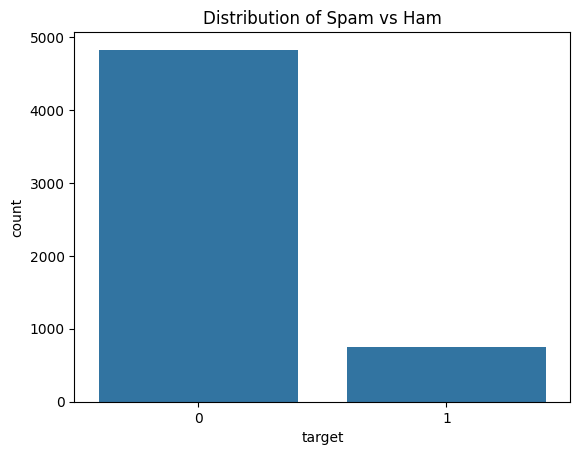

In [62]:
# Drop unnecessary columns (if any exist, based on inspection, none needed here)
# Based on df.info(), the dataset only has 'Category' and 'Message' columns. The original instruction might have been for a slightly different dataset.
# So, directly rename the existing columns.

# Rename columns for clarity
df.rename(columns={'Category': 'target', 'Message': 'text'}, inplace=True)

# Map target variable to numerical (0 for 'ham', 1 for 'spam')
df['target'] = df['target'].map({'ham': 0, 'spam': 1})

print("Dataset after cleaning and renaming columns:")
display(df.head())
display(df['target'].value_counts())

sns.countplot(x='target', data=df)
plt.title('Distribution of Spam vs Ham')
plt.show()

### 1.3 Text Cleaning Function

In [63]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation, special characters, and numbers
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Split into words
    words = text.split()

    # Remove stopwords and lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # Join words back into a string
    text = ' '.join(words)

    return text

# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)

print("\nOriginal Text vs. Cleaned Text:")
display(df[['text', 'cleaned_text']].head())


Original Text vs. Cleaned Text:


,text,cleaned_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah think go usf life around though


## Step 2: Feature Extraction (Vectorization)

In [64]:
# Initialize CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform the cleaned text data
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['target']

print("Shape of feature matrix (X):")
print(X.shape)

print("Shape of target vector (y):")
print(y.shape)

# Display a sample of the vectorized data (first 5 messages)
# Note: This will be a sparse matrix, so converting to array for display
print("\nSample of vectorized data (first 5 rows and a few features):")
display(pd.DataFrame(X[:5].toarray(), columns=vectorizer.get_feature_names_out()).head())

Shape of feature matrix (X):
(5572, 7100)
Shape of target vector (y):
(5572,)

Sample of vectorized data (first 5 rows and a few features):


,aa,aah,aaniye,aaooooright,aathi,ab,abbey,abdomen,abeg,abel,...,zed,zero,zf,zhong,zindgi,zoe,zogtorius,zoom,zouk,zyada
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## Step 3: Data Splitting

In [65]:
# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target in training set:")
display(y_train.value_counts(normalize=True))

print("\nDistribution of target in testing set:")
display(y_test.value_counts(normalize=True))

X_train shape: (4457, 7100)
X_test shape: (1115, 7100)
y_train shape: (4457,)
y_test shape: (1115,)

Distribution of target in training set:


,proportion
target,
0,0.865829
1,0.134171



Distribution of target in testing set:


,proportion
target,
0,0.866368
1,0.133632


## Step 4: Algorithms Development (The 5 Models)

### 4.1 Helper Function for Evaluation

In [66]:
def evaluate_model(model_name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("\n")

    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1-Score": f1}

### 4.2 Naive Bayes (MultinomialNB)

In [67]:
# Initialize and train the Multinomial Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# Evaluate the model
nb_metrics = evaluate_model("Naive Bayes", y_test, y_pred_nb)

--- Naive Bayes ---
Accuracy:  0.9740
Precision: 0.8750
Recall:    0.9396
F1-Score:  0.9061




### 4.3 Logistic Regression

In [68]:
# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
lr_model=LogisticRegression(class_weight='balanced')
lr_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test)

# Evaluate the model
lr_metrics = evaluate_model("Logistic Regression", y_test, y_pred_lr)

--- Logistic Regression ---
Accuracy:  0.9821
Precision: 0.9640
Recall:    0.8993
F1-Score:  0.9306




### 4.4 Support Vector Machine (SVM)

In [86]:
# Initialize and train the Support Vector Machine model
svm_model = SVC(kernel='linear', random_state=42)
svm_model=SVC(class_weight='balanced')
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)

# Evaluate the model
svm_metrics = evaluate_model("Support Vector Machine", y_test, y_pred_svm)

--- Support Vector Machine ---
Accuracy:  0.9785
Precision: 1.0000
Recall:    0.8389
F1-Score:  0.9124




### 4.5 Decision Tree

In [83]:
# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model = DecisionTreeClassifier(class_weight='balanced')
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
dt_metrics = evaluate_model("Decision Tree", y_test, y_pred_dt)

--- Decision Tree ---
Accuracy:  0.9668
Precision: 0.8784
Recall:    0.8725
F1-Score:  0.8754




### 4.6 Deep Learning (Simple Feed-Forward Neural Network)

In [71]:
# Build the Deep Learning model
dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
dl_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
# Convert sparse matrix to dense for TensorFlow
X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

dl_model.fit(X_train_dense, y_train, epochs=5, batch_size=32, validation_split=0.1, verbose=0)

# Make predictions on the test set
y_pred_dl_prob = dl_model.predict(X_test_dense)
y_pred_dl = (y_pred_dl_prob > 0.5).astype(int)

# Evaluate the model
dl_metrics = evaluate_model("Deep Learning (Neural Network)", y_test, y_pred_dl)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
--- Deep Learning (Neural Network) ---
Accuracy:  0.9830
Precision: 0.9851
Recall:    0.8859
F1-Score:  0.9329




## Step 5: Graphical User Interface (GUI) - Using Gradio

In [87]:
# Install Gradio
!pip install gradio -qq
import gradio as gr

# Ensure the necessary functions and objects are accessible
# clean_text, vectorizer, nb_model, lr_model, svm_model, dt_model, dl_model should be available from previous steps

def predict_spam_ham_gradio(user_input):
    if not user_input:
        return "Please enter some text to analyze.", "", "", "", ""

    # 1. Clean the input text
    cleaned_input = clean_text(user_input)

    # 2. Vectorize the cleaned text
    input_vectorized = vectorizer.transform([cleaned_input])

    # 3. Make predictions with each model

    # Naive Bayes
    nb_prediction = nb_model.predict(input_vectorized)[0]
    nb_result = "Spam" if nb_prediction == 1 else "Ham"

    # Logistic Regression
    lr_prediction = lr_model.predict(input_vectorized)[0]
    lr_result = "Spam" if lr_prediction == 1 else "Ham"

    # Support Vector Machine
    svm_prediction = svm_model.predict(input_vectorized)[0]
    svm_result = "Spam" if svm_prediction == 1 else "Ham"

    # Decision Tree
    dt_prediction = dt_model.predict(input_vectorized)[0]
    dt_result = "Spam" if dt_prediction == 1 else "Ham"

    # Deep Learning
    input_vectorized_dense = input_vectorized.toarray()
    dl_prediction_prob = dl_model.predict(input_vectorized_dense, verbose=0)[0][0]
    dl_prediction = (dl_prediction_prob > 0.5).astype(int)
    dl_result = "Spam" if dl_prediction == 1 else "Ham"

    return (
        f"Naive Bayes: {nb_result}",
        f"Logistic Regression: {lr_result}",
        f"SVM: {svm_result}",
        f"Decision Tree: {dt_result}",
        f"Deep Learning: {dl_result}"
    )

# Create Gradio Interface
iface = gr.Interface(
    fn=predict_spam_ham_gradio,
    inputs=gr.Textbox(lines=5, label="Enter your message here:"),
    outputs=[
        gr.Textbox(label="Naive Bayes Prediction"),
        gr.Textbox(label="Logistic Regression Prediction"),
        gr.Textbox(label="SVM Prediction"),
        gr.Textbox(label="Decision Tree Prediction"),
        gr.Textbox(label="Deep Learning Prediction")
    ],
    title="Spam Detection System",
)

# Launch the interface
iface.launch(debug=True)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://6055c374d24748cf57.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://6055c374d24748cf57.gradio.live
